# MNIST

MNIST é um tipo de rede neural que é utilizada para interpretar números em imagens e extraí-los para texto.

É uma solução utilizada para resolver endereços escritos a mão, em fotografias, mapas virtuais, cheques, reconhecimento de cálculos e outras situações que envolvam o trabalho com números.

In [68]:
import numpy as np
import torch
import torch.nn.functional as F
from torch import nn, optim
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from time import time

In [69]:
transform = transforms.ToTensor() #definindo a conversão de imagem para tensor

trainset = datasets.MNIST('./MNIST_data/', download=True, train=True, transform=transform) # Carrega a parte de treino do dataset
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True) # Cria um buffer para pegar os dados por partes

valset = datasets.MNIST('./MNIST_data/', download=True, train=False, transform=transform) # Carrega a parte de validação do dataset
valloader = torch.utils.data.DataLoader(valset, batch_size=64, shuffle=True) # Cria um buffer para pegar os dados por partes

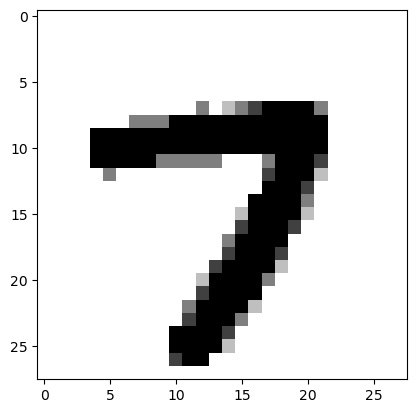

In [70]:
# Visualizando uma imagem aleatória do dataset
dataiter = iter(trainloader)
images, labels = next(dataiter)
plt.imshow(images[0].numpy().squeeze(), cmap='gray_r')

In [71]:
print(images[0].shape)  # Verificando as dimensões do Tensor da imagem
print(labels[0])        # Rótulo da imagem
print(labels[0].shape)  # Dimensões do Rótulo

torch.Size([1, 28, 28])
tensor(7)
torch.Size([])


In [72]:
# Estrutura da Rede Neural
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.linear1 = nn.Linear(28*28, 128)    # Camada de entrada, pega 784 neurônios (28x28) e fazem a ligação para 128 neurônios ocultos
        self.linear2 = nn.Linear(128, 64)       # Camada oculta 1, pega 128 neurônios e fazem a ligação para 64 neurônios ocultos
        self.linear3 = nn.Linear(64, 10)        # Camada oculta 2, pega 64 neurônios e fazem a ligação para 10 neurônios de saída (0-9 dígitos)

    def forward(self, x):
        x = F.relu(self.linear1(x))  # Função de ativação ReLU na camada oculta 1
        x = F.relu(self.linear2(x))  # Função de ativação ReLU na camada oculta 2
        x = self.linear3(x)          # Camada de saída, com a função f(x) = x
        return F.log_softmax(x, dim=1)  # Dados utilizados para calcular a perda


In [85]:
# Treinamento da Rede Neural
def train(model, trainloader, device):
    
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)  # Otimizador Stochastic Gradient Descent, define atualização dos pesos e bias
    start = time() # Marca o tempo de início do treinamento

    criterion = nn.NLLLoss()  # Função de perda Negative Log Likelihood Loss, define o quão ruim a previsão está em relação ao rótulo real
    EPOCHS = 100  # Número de épocas para o treinamento
    model.train() # Ativa o modo de treinamento do modelo

    for epoch in range(EPOCHS):
        running_loss = 0

        for images, labels in trainloader:
            images = images.view(images.shape[0], -1) # convertendo as imagens para "vetores de 28x28 casas para ficarem compatíveis com a rede neural
            optimizer.zero_grad()  # Zera os gradientes acumulados no ciclo anterior

            output = model(images.to(device))  # colocando os dados no modelo
            instant_loss = criterion(output, labels.to(device))  # Calcula a perda da EPOCH

            instant_loss.backward()  # Propaga o erro para calcular os gradientes
            optimizer.step()  # Atualiza os pesos e bias com base nos gradientes calculados
            running_loss += instant_loss.item()  # Acumula a perda para exibição
        
        else:
            print(f'Época {epoch+1} - Perda: {running_loss/len(trainloader)}')

    print(f'Tempo total de treinamento: {time()-start} segundos')

In [79]:
# Validação da Rede Neural com imagens de teste desconhecidas por ela
def validation(model, valloader, device):
    correct = 0
    total = 0
    model.eval()
    
    for images, labels in valloader:
        for i in range(len(labels)):
            img = images[i].view(1, 784)  # Redimensiona a imagem para um vetor de 784 casas
            img = img.to(device)  # Move a imagem para o dispositivo definido (GPU ou CPU)

            with torch.no_grad():  # Desativa o cálculo de gradientes para economizar memória
                output_log = model(img.to(device))  # Coloca a imagem no modelo e obtém a saída

            converted_output = torch.exp(output_log)  # Converte a saída logarítmica para probabilidades

            probab = list(converted_output.cpu().numpy()[0])  # Converte a saída para uma lista de probabilidades, sendo o número que o modelo imagina que representa a imagem
            pred_label = probab.index(max(probab))  # Obtém o rótulo previsto com a maior probabilidade
            true_label = labels.numpy()[i]  # Obtém o rótulo verdadeiro da imagem
            if(pred_label == true_label):
                correct += 1  # Incrementa o contador de acertos se a previsão estiver correta
            total += 1  # Incrementa o contador total de imagens avaliadas
    print(f'Total de imagens: {total}')
    print(f'Número de acertos: {correct}')
    print(f'Precisão do modelo: {round((correct/total)*100, 2)}%')

In [75]:
model = Model()  # Instancia o modelo da rede neural

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Define o dispositivo de computação (GPU ou CPU)
model.to(device)  # Move o modelo para o dispositivo definido

Model(
  (linear1): Linear(in_features=784, out_features=128, bias=True)
  (linear2): Linear(in_features=128, out_features=64, bias=True)
  (linear3): Linear(in_features=64, out_features=10, bias=True)
)

In [86]:
train(model, trainloader, device)  # Chama a função de treinamento

Época 1 - Perda: 0.04401384953827436
Época 2 - Perda: 0.04219558142470136
Época 3 - Perda: 0.040226771612651646
Época 4 - Perda: 0.03854271911108481
Época 5 - Perda: 0.03693880697365787
Época 6 - Perda: 0.03542267346704033
Época 7 - Perda: 0.03371228348488099
Época 8 - Perda: 0.03233578508031735
Época 9 - Perda: 0.031124643348743205
Época 10 - Perda: 0.029533339823697453
Época 11 - Perda: 0.02819362838580303
Época 12 - Perda: 0.02711761197664026
Época 13 - Perda: 0.025955199187538074
Época 14 - Perda: 0.024672668617055405
Época 15 - Perda: 0.024012901146448395
Época 16 - Perda: 0.022724950199957683
Época 17 - Perda: 0.021876551371354705
Época 18 - Perda: 0.020837380607892423
Época 19 - Perda: 0.020057416677391575
Época 20 - Perda: 0.01900398460969424
Época 21 - Perda: 0.018254490881867366
Época 22 - Perda: 0.017689815783964547
Época 23 - Perda: 0.016696848978746688
Época 24 - Perda: 0.01604302140495885
Época 25 - Perda: 0.01543533577368275
Época 26 - Perda: 0.014943769462888183
Época 2

In [90]:
validation(model, valloader, device)  # Chama a função de validação

Total de imagens: 10000
Número de acertos: 9784
Precisão do modelo: 97.84%
